In [1]:
import juliet
import numpy as np
import matplotlib.pyplot as plt 

In [13]:
from lightkurve import search_lightcurvefile
import lightkurve as lk

TIC = 269701147
TOI_id = 'TOI 1339'
# t,f,ferr = juliet.get_TESS_data('https://archive.stsci.edu/hlsps/tess-data-alerts/'+\
#                                 f'hlsp_tess-data-alerts_tess_phot_00{TIC}-s**'+\
#                                 'tess_v1_lc.fits')

# Search for TESS lightcurve files
search_result = lk.search_lightcurve(f"TIC {TIC}", author='SPOC')
print(search_result)
# Extract flux and time
# t, f, ferr = juliet.get_TESS_data(lc_files[0].path)


SearchResult containing 47 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
  9 TESS Sector 41 2021   SPOC      20   269701147      0.0
 10 TESS Sector 41 2021   SPOC     120   269701147      0.0
 11 TESS Sector 60 2022   SPOC      20   269701147      0.0
 12 TESS Sector 56 2022   SPOC      20   269701147      0

In [14]:
# Use the `.table` attribute to filter and access data
table = search_result.table

# Get missions (sectors) that have 20-second exposures
sectors_with_20s = set(table[table['exptime'] == 20]['mission'])

print(sectors_with_20s)

{'TESS Sector 82', 'TESS Sector 86', 'TESS Sector 48', 'TESS Sector 60', 'TESS Sector 41', 'TESS Sector 49', 'TESS Sector 59', 'TESS Sector 56', 'TESS Sector 55', 'TESS Sector 77', 'TESS Sector 83', 'TESS Sector 85', 'TESS Sector 78', 'TESS Sector 75', 'TESS Sector 73', 'TESS Sector 76', 'TESS Sector 79', 'TESS Sector 52', 'TESS Sector 51'}


In [15]:
# Now build filtered list, preferring 20s over 120s
filtered_results = []

for mission in set(table['mission']):
    if mission in sectors_with_20s:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 20)]
    else:
        result = search_result[(search_result.table['mission'] == mission) & (search_result.table['exptime'] == 120)]
    if len(result) > 0:
        filtered_results.append(result[0])
# print(filtered_results)

In [16]:
# Create final SearchResult
from lightkurve.search import SearchResult
from astropy.table import vstack
# Extract the table rows from each mini SearchResult
filtered_tables = [sr.table[0] for sr in filtered_results]

# Stack them into one Astropy Table
stacked_table = vstack(filtered_tables)

# Create final SearchResult
filtered_search = SearchResult(stacked_table)

# Download all matching light curves
lc_collection = filtered_search.download_all()


# lc_collection = search_result.download_all()
print(lc_collection)

LightCurveCollection of 28 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

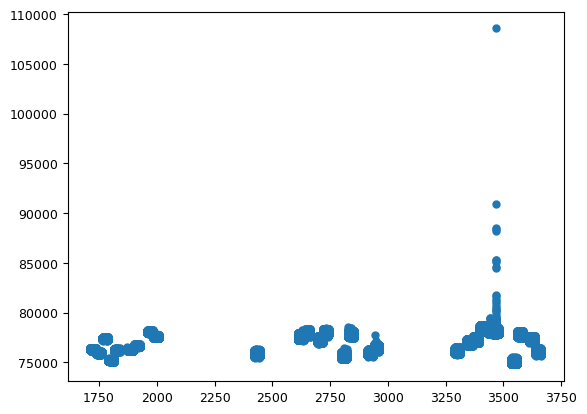

In [21]:
t_all = np.concatenate([lc.time.value for lc in lc_collection])
f_all = np.concatenate([lc.flux for lc in lc_collection])
ferr_all = np.concatenate([lc.flux_err for lc in lc_collection])
plt.scatter(t_all, f_all.value)
plt.show()